In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_excel('/content/EastWestAirlines.xlsx', sheet_name ='data')
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [7]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [8]:
df.shape

(3999, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [11]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [14]:
# Remove ID column
df = df.drop('ID#', axis=1)

df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [15]:
df.shape

(3999, 11)

<Axes: >

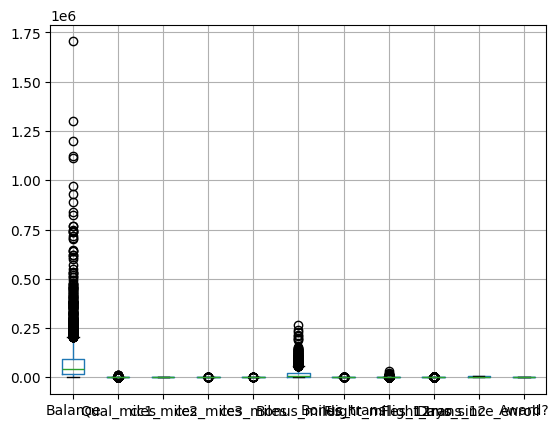

In [16]:
df.boxplot()

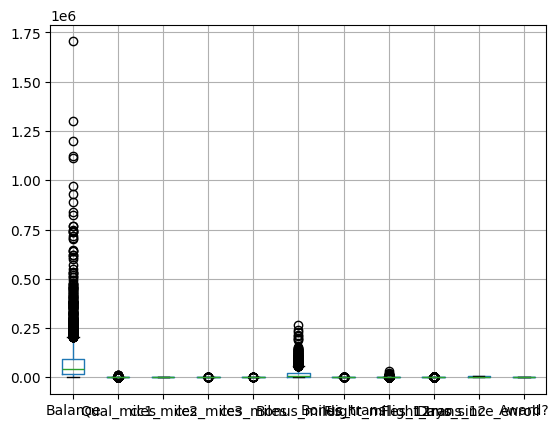

In [19]:
#Checking outliers
df.boxplot()
plt.show()

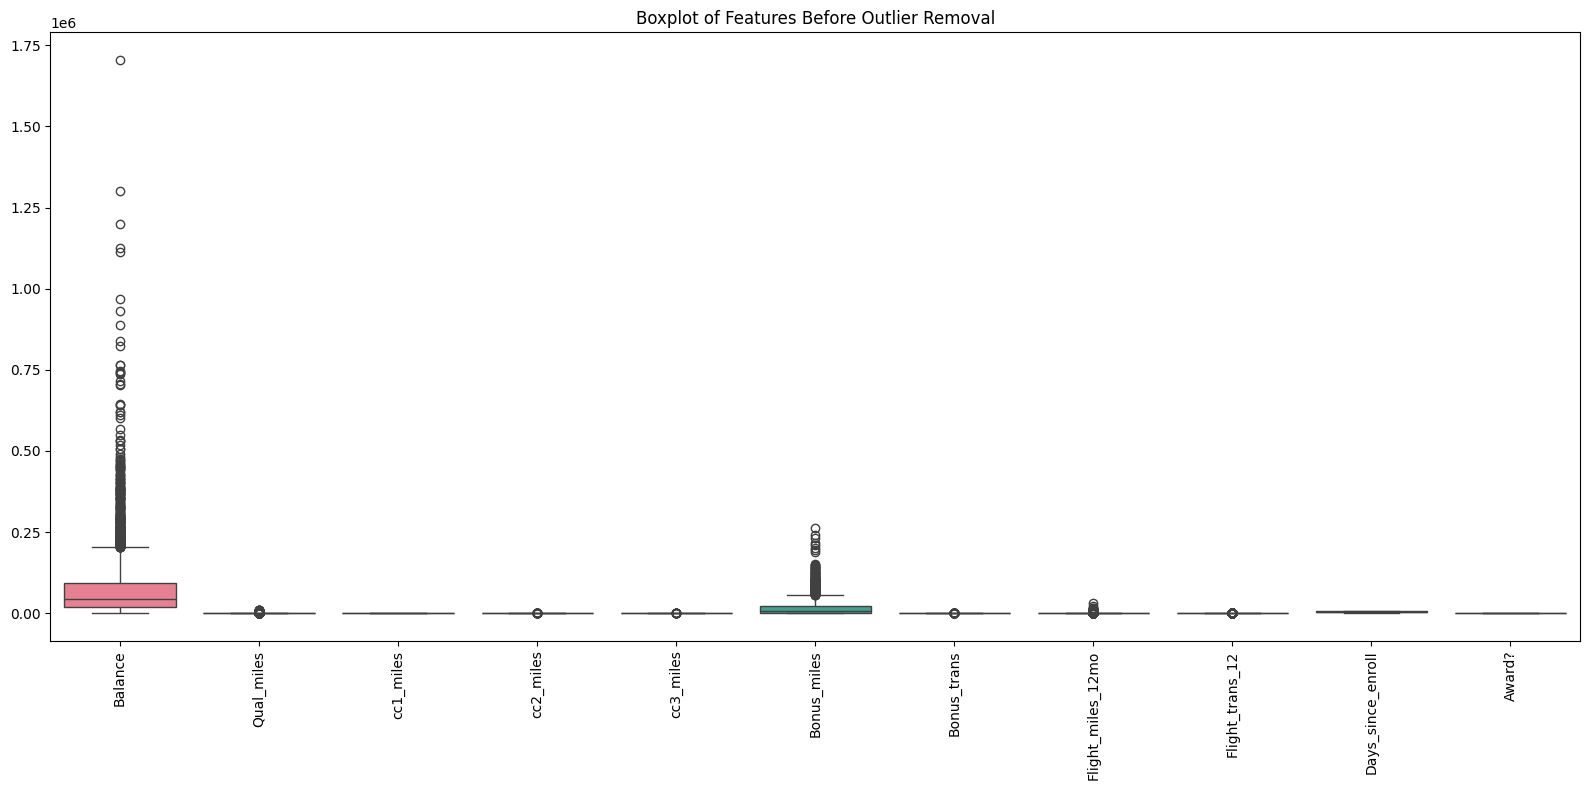

In [20]:
# Check outliers using boxplots

plt.figure(figsize=(16, 8))

sns.boxplot(data=df)

plt.xticks(rotation=90)
plt.title('Boxplot of Features Before Outlier Removal')
plt.tight_layout()
plt.show()


In [21]:
# Count outliers using IQR

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outlier_count = ((df < (Q1 - 1.5 * IQR)) |
                 (df > (Q3 + 1.5 * IQR))).sum()

print("Outliers in each feature:")
print(outlier_count)

Outliers in each feature:
Balance              266
Qual_miles           226
cc1_miles              0
cc2_miles             43
cc3_miles             18
Bonus_miles          280
Bonus_trans           63
Flight_miles_12mo    569
Flight_trans_12      565
Days_since_enroll      0
Award?                 0
dtype: int64


In [22]:
# Remove outliers using IQR method

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

print("Original shape:", df.shape)
print("Shape after outlier removal:", df_clean.shape)

Original shape: (3999, 11)
Shape after outlier removal: (2875, 11)


In [23]:
df = df_clean.copy()

df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
5,16420,0,1,1,1,0,0,0,0,6942,0


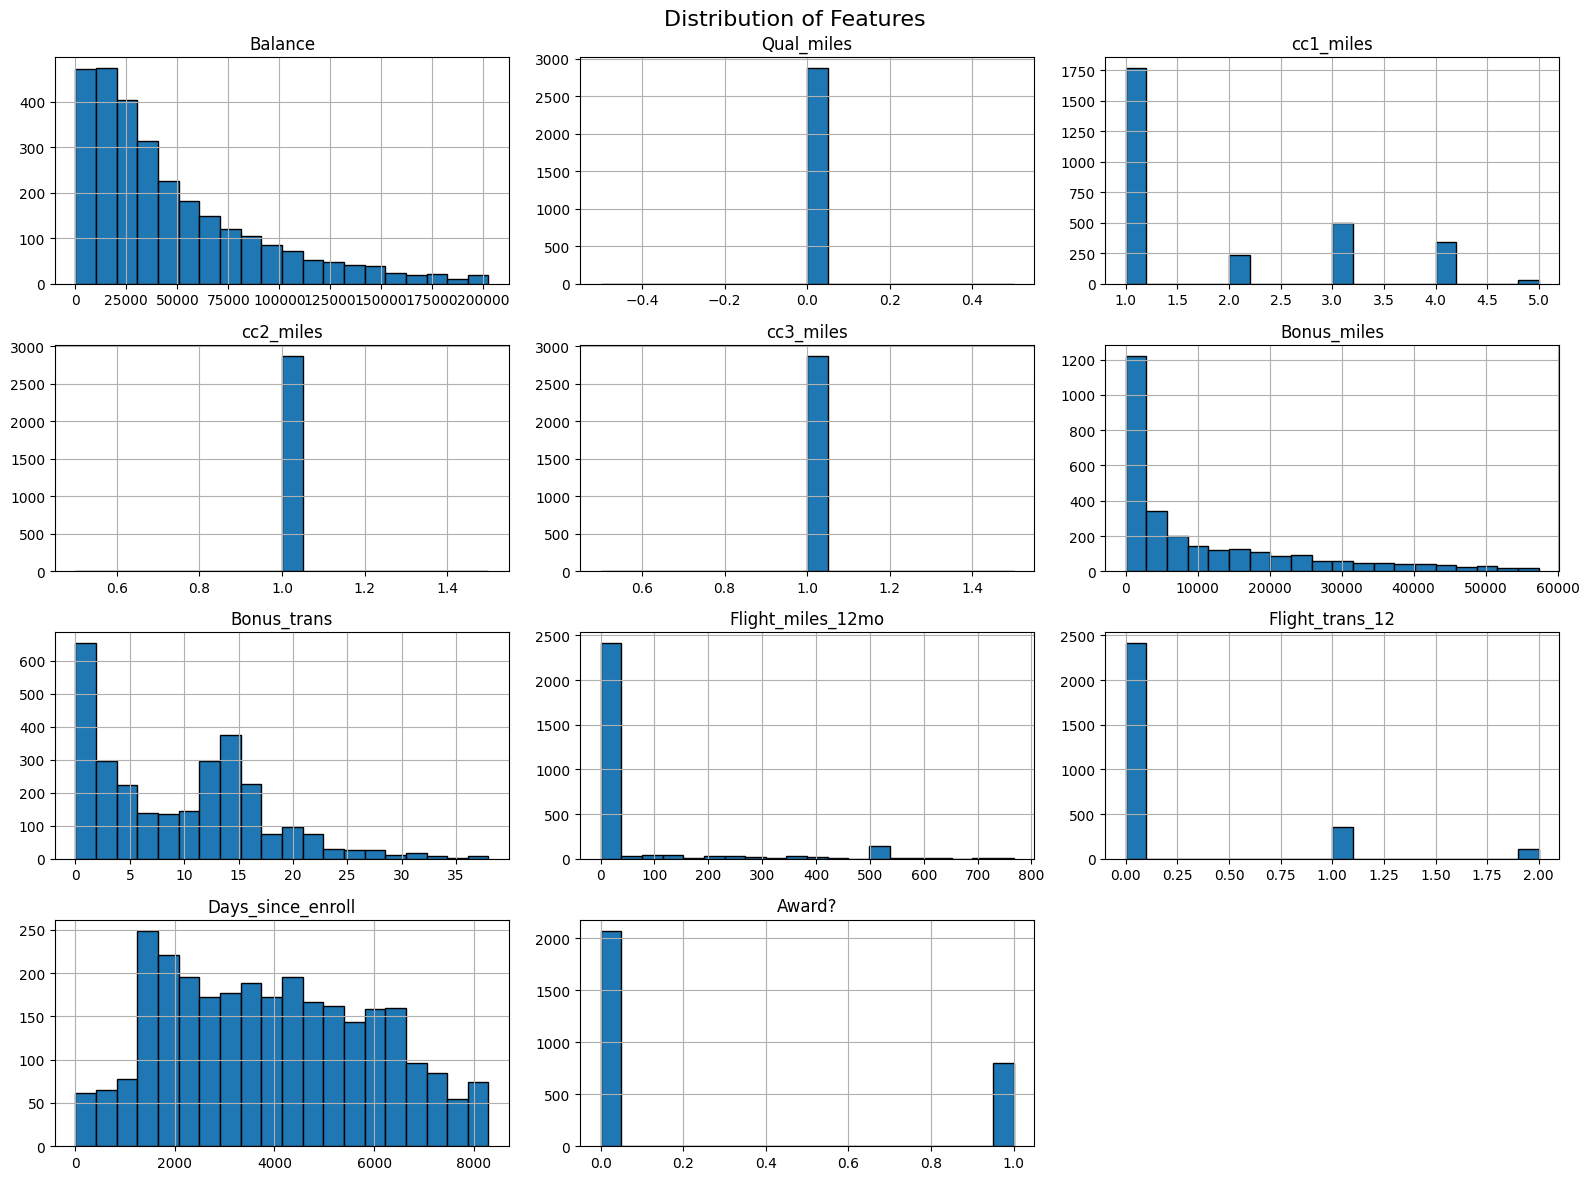

In [24]:
# Histograms of all features

df.hist(figsize=(16, 12), bins=20, edgecolor='black')

plt.suptitle('Distribution of Features', fontsize=16)
plt.tight_layout()
plt.show()

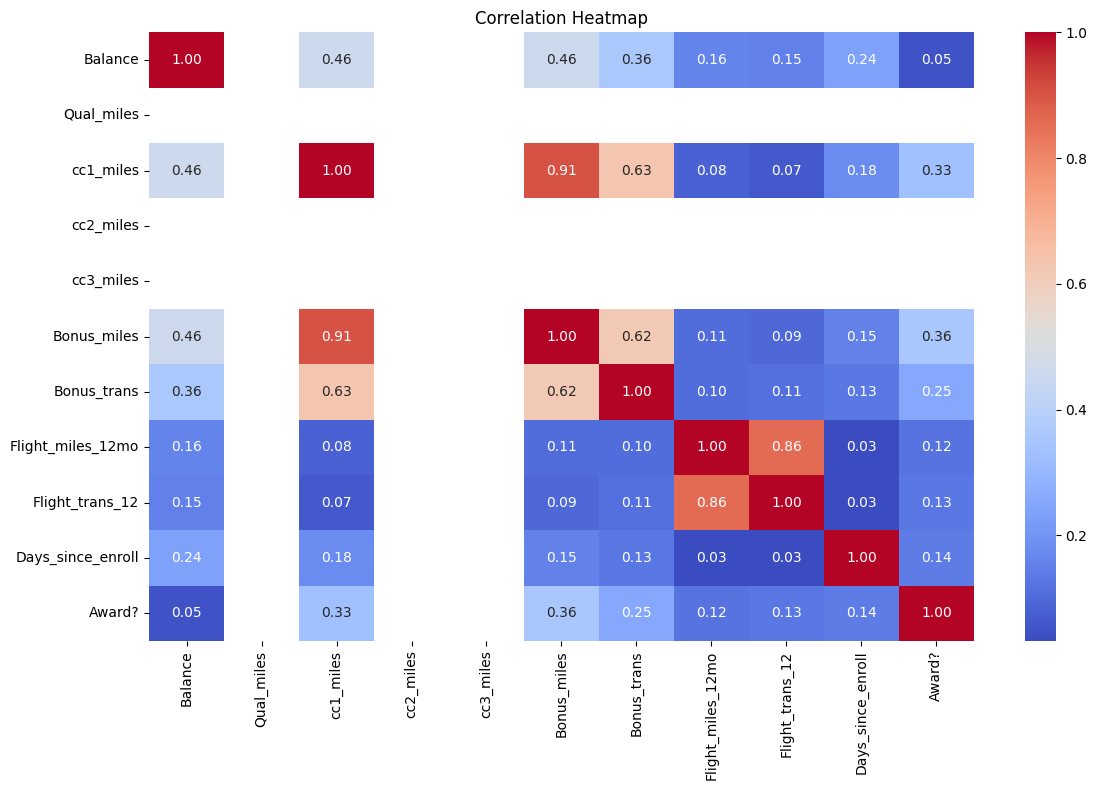

In [25]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

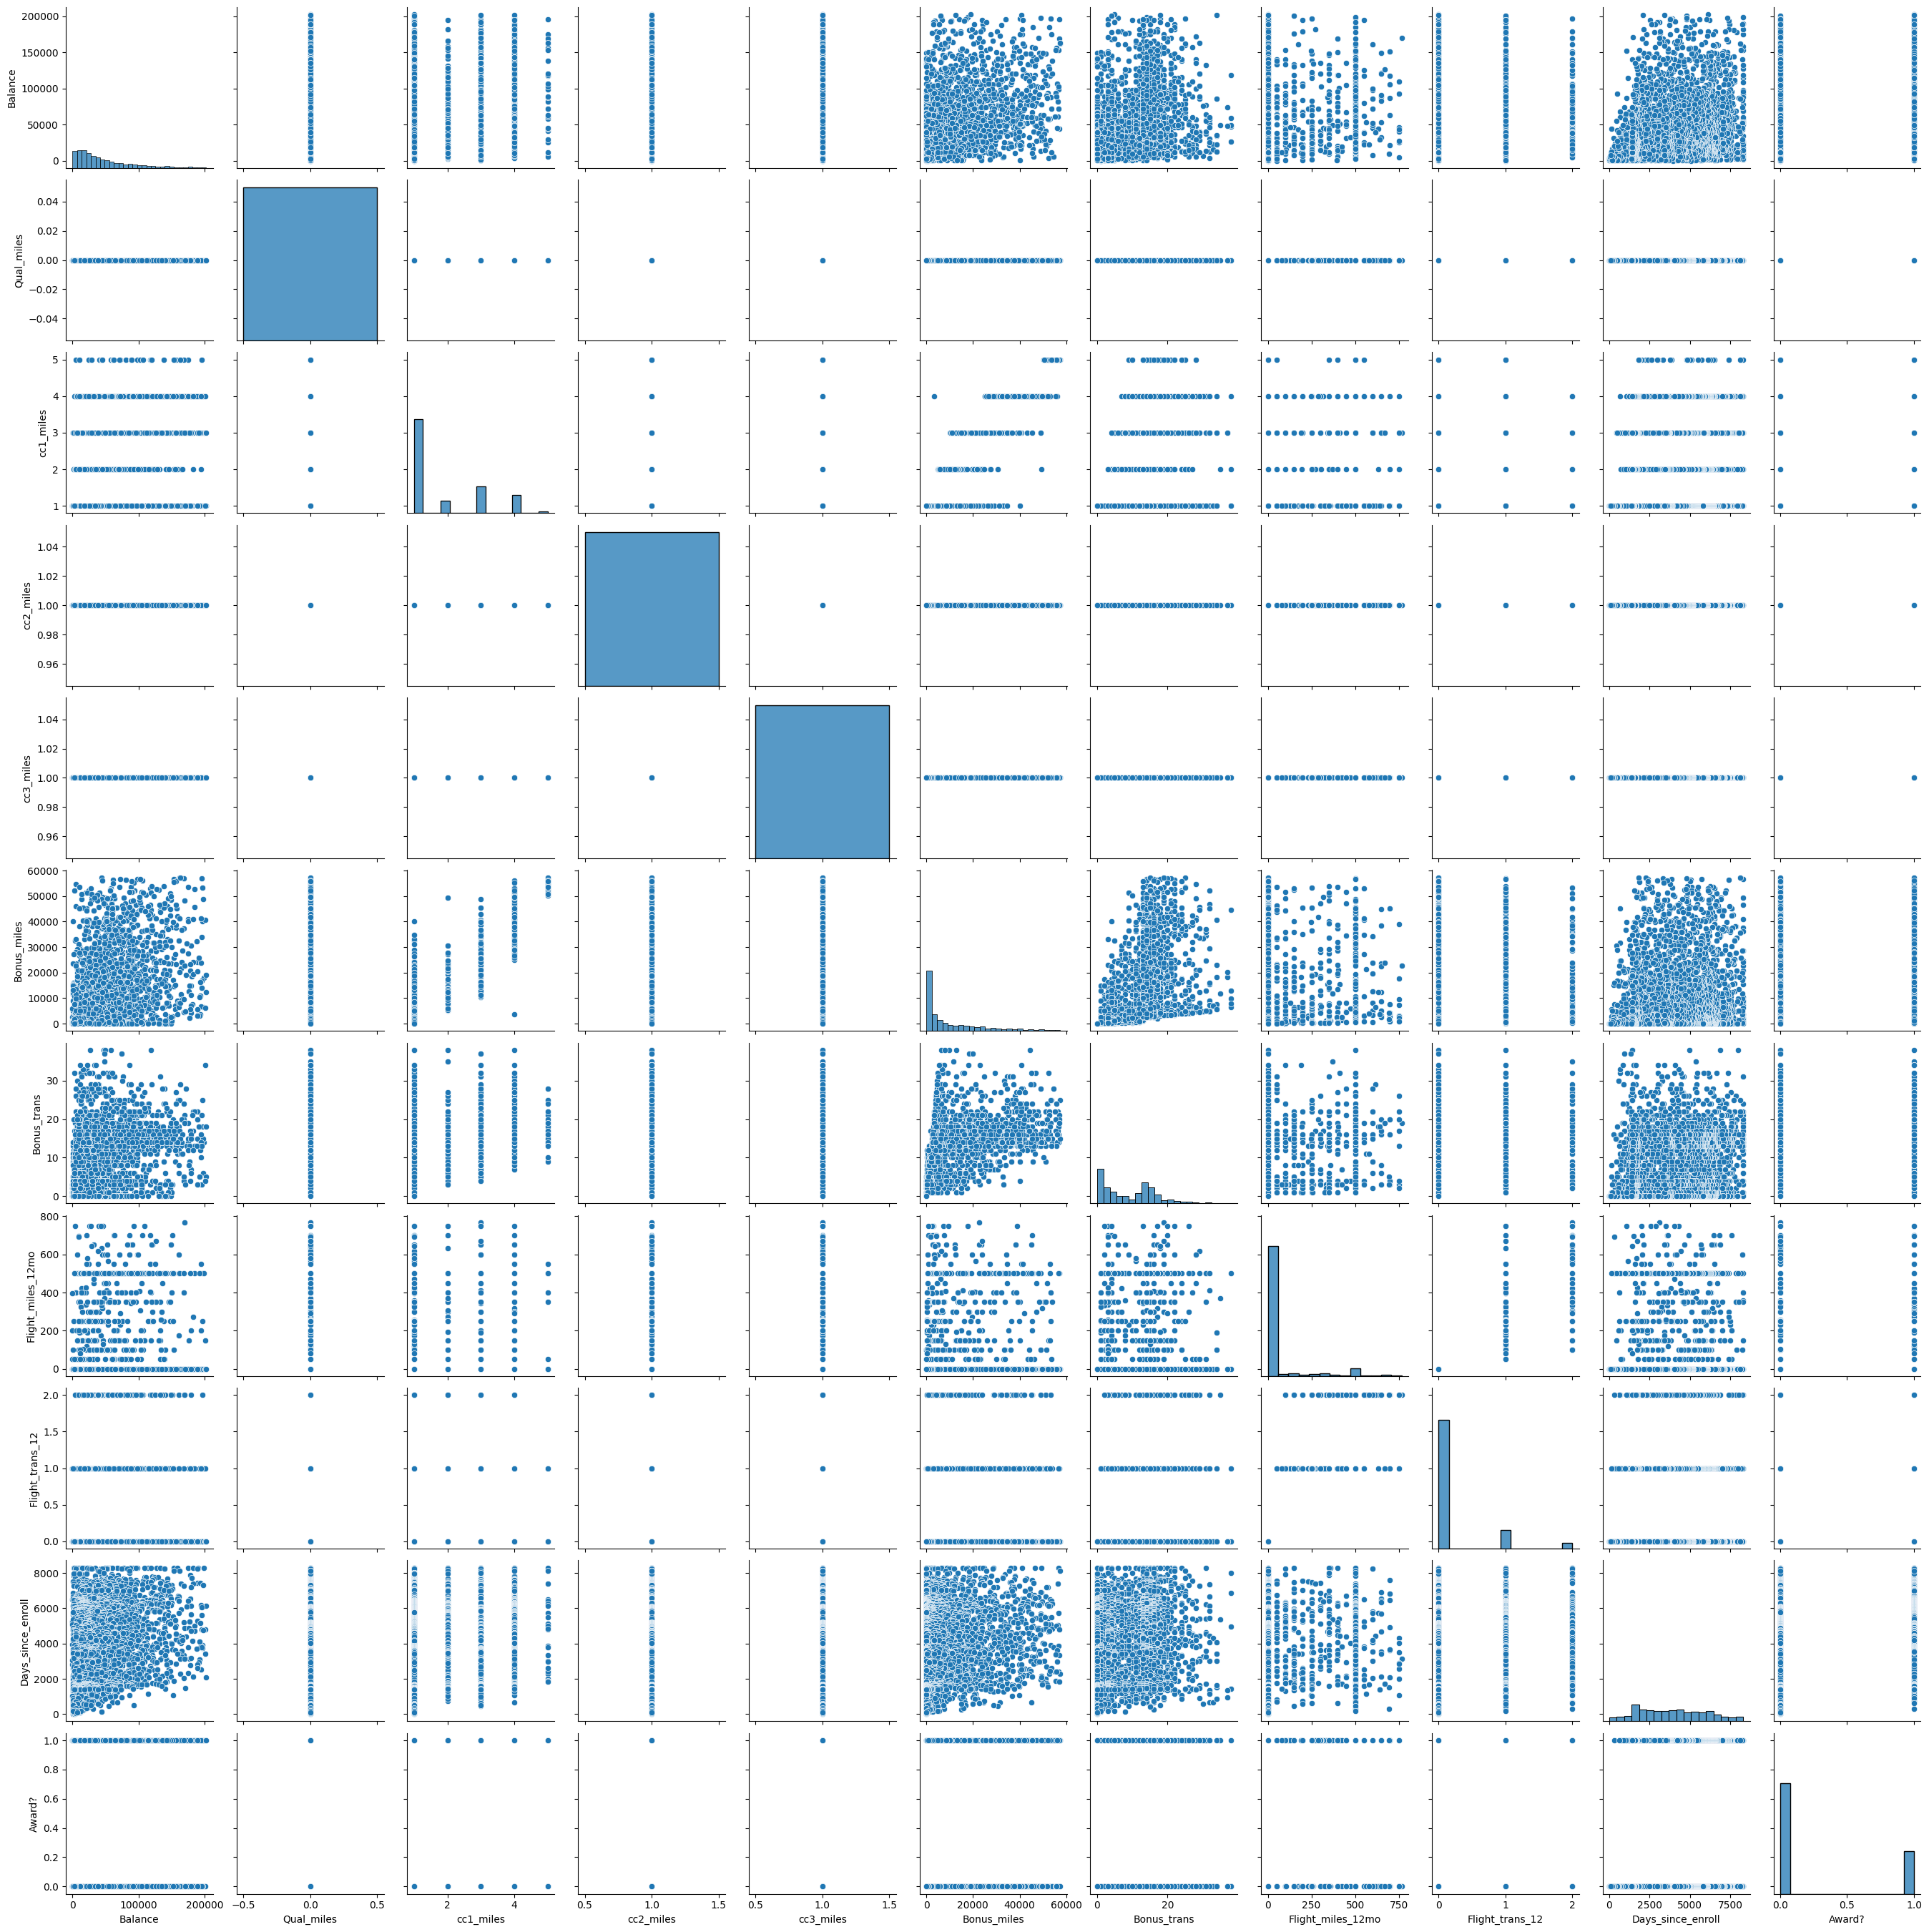

In [26]:
# Pairplot to identify hidden patterns

sns.pairplot(df)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2875, 11)


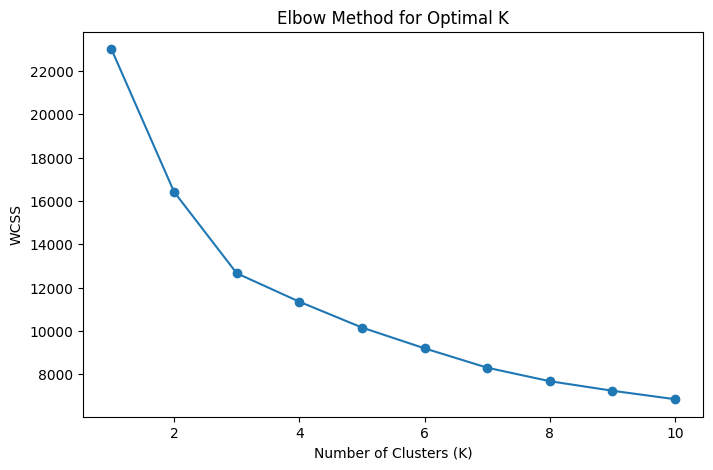

In [28]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [29]:
# Apply K-Means with K = 4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print("Cluster counts:")
print(df['KMeans_Cluster'].value_counts().sort_index())

Cluster counts:
KMeans_Cluster
0    1543
1     453
2     340
3     539
Name: count, dtype: int64


In [30]:
# Cluster centers

cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)

cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=df.drop('KMeans_Cluster', axis=1).columns
)

cluster_centers_df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,26305.632296,0.0,1.042153,1.0,1.0,2285.070687,4.773671,4.389754,0.035668,3525.487030,0.127108
1,53761.516556,0.0,3.130243,1.0,1.0,25830.536424,15.997792,12.152318,0.083885,4594.485651,1.000000
2,64984.885630,0.0,1.997067,1.0,1.0,13858.105572,11.404692,435.771261,1.319648,4129.645161,0.436950
3,88290.831169,0.0,2.884972,1.0,1.0,20981.909091,15.745826,6.025974,0.051948,4386.265306,0.011132


In [31]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.32076573171912565


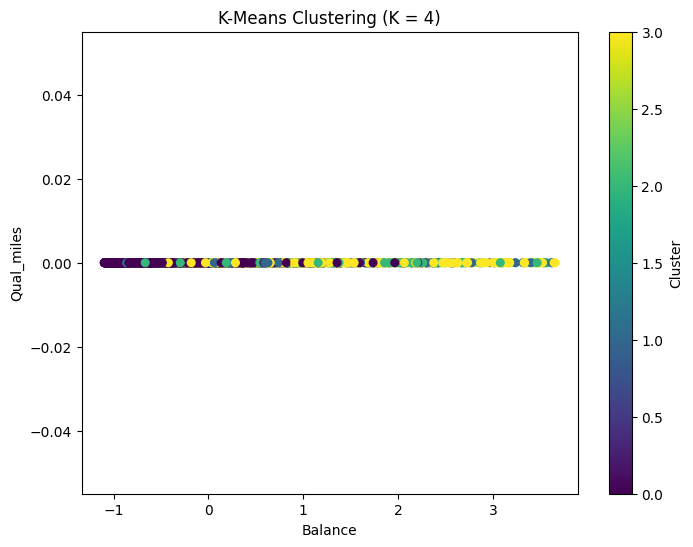

In [32]:
# Visualize K-Means clusters using the first two scaled features

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=30
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('K-Means Clustering (K = 4)')
plt.colorbar(label='Cluster')

plt.show()

In [33]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("DBSCAN Cluster Counts:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Cluster Counts:
DBSCAN_Cluster
-1     115
 0    1805
 1     124
 2     602
 3     180
 4      37
 5       7
 6       5
Name: count, dtype: int64


In [34]:
from sklearn.metrics import silhouette_score

# Remove DBSCAN noise points (-1)
mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

print("DBSCAN Silhouette Score:", dbscan_silhouette)

DBSCAN Silhouette Score: 0.2673349072078038


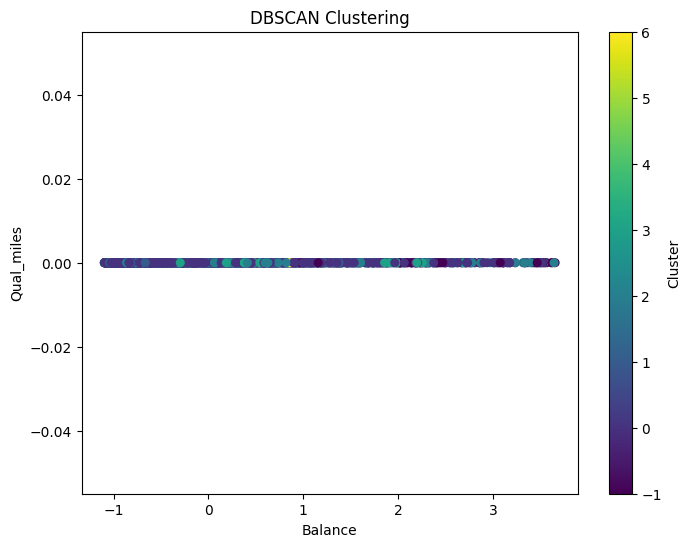

In [36]:
# Visualize DBSCAN clusters

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    s=30
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('DBSCAN Clustering')
plt.colorbar(label='Cluster')

plt.show()

In [37]:
# K-Means Cluster Analysis

kmeans_analysis = df.groupby('KMeans_Cluster').mean(numeric_only=True)

print("K-Means Cluster Characteristics:")
kmeans_analysis

K-Means Cluster Characteristics:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,
0,26357.586520,0.0,1.042126,1.0,1.0,2289.062216,4.773817,4.451717,0.036293,3527.233312,0.127025,0.339598
1,53761.516556,0.0,3.130243,1.0,1.0,25830.536424,15.997792,12.152318,0.083885,4594.485651,1.000000,1.830022
2,64862.867647,0.0,2.000000,1.0,1.0,13874.029412,11.423529,436.758824,1.320588,4123.497059,0.438235,1.647059
3,88290.831169,0.0,2.884972,1.0,1.0,20981.909091,15.745826,6.025974,0.051948,4386.265306,0.011132,0.098330


In [38]:
# DBSCAN Cluster Analysis

dbscan_analysis = df.groupby('DBSCAN_Cluster').mean(numeric_only=True)

print("DBSCAN Cluster Characteristics:")
dbscan_analysis

DBSCAN Cluster Characteristics:


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
DBSCAN_Cluster,,,,,,,,,,,,
-1,103574.400000,0.0,2.626087,1.0,1.0,21837.817391,17.382609,368.356522,1.469565,4901.565217,0.617391,1.947826
0,42801.730194,0.0,1.567867,1.0,1.0,7473.067590,7.873684,0.000000,0.000000,3717.924100,0.000000,0.839335
1,41631.967742,0.0,2.411290,1.0,1.0,19086.629032,11.838710,338.854839,1.000000,4091.209677,1.000000,1.645161
2,46506.757475,0.0,2.431894,1.0,1.0,18152.727575,12.192691,0.000000,0.000000,4391.569767,1.000000,0.705980
3,57542.688889,0.0,1.694444,1.0,1.0,9664.983333,9.205556,322.661111,1.000000,3885.416667,0.000000,1.577778
4,39179.270270,0.0,1.027027,1.0,1.0,2568.972973,5.270270,433.486486,2.000000,3613.297297,0.000000,2.000000
5,24826.714286,0.0,1.000000,1.0,1.0,3270.857143,6.142857,396.142857,2.000000,2555.428571,1.000000,2.000000
6,71428.200000,0.0,3.200000,1.0,1.0,21422.000000,14.000000,570.000000,2.000000,2697.200000,0.000000,2.000000


In [39]:
# Cluster Analysis - Insights

print("""
K-Means Insights:
- K-Means divided the customers into 4 clusters.
- Cluster sizes are different, indicating that customer groups are not equally distributed.
- The cluster mean values can be compared to understand differences in customer behaviour.
- Customers in each cluster can be interpreted based on features such as balance, purchases,
  credit limit, cash advance, and transaction frequency.

DBSCAN Insights:
- DBSCAN identified several clusters and also detected noise points labelled as -1.
- The noise points represent customers that do not belong clearly to any dense cluster.
- DBSCAN can identify irregularly shaped groups and does not require the number of clusters
  to be specified in advance.

Model Comparison:
- K-Means obtained a silhouette score of approximately 0.321.
- DBSCAN obtained a silhouette score of approximately 0.267.
- Based on silhouette score, K-Means produced better-separated clusters for this dataset.
""")


K-Means Insights:
- K-Means divided the customers into 4 clusters.
- Cluster sizes are different, indicating that customer groups are not equally distributed.
- The cluster mean values can be compared to understand differences in customer behaviour.
- Customers in each cluster can be interpreted based on features such as balance, purchases,
  credit limit, cash advance, and transaction frequency.

DBSCAN Insights:
- DBSCAN identified several clusters and also detected noise points labelled as -1.
- The noise points represent customers that do not belong clearly to any dense cluster.
- DBSCAN can identify irregularly shaped groups and does not require the number of clusters
  to be specified in advance.

Model Comparison:
- K-Means obtained a silhouette score of approximately 0.321.
- DBSCAN obtained a silhouette score of approximately 0.267.
- Based on silhouette score, K-Means produced better-separated clusters for this dataset.



Conclusion :- K-Means performed better than DBSCAN for this dataset based on the silhouette score, with K-Means achieving 0.321 compared with DBSCAN's 0.267.